# Part 1: Population generation

In [1]:
from scipy.special import expit
import numpy as np
import pandas as pd


def generate_synthetic_population(n_pop=10_000, rng=None):
    regions = ["Manicaland", "Harare", "Midlands", "Masvingo", "Bulawayo"]
    genders = ["Male", "Female"]
    age_buckets = ["18-24", "25-29", "30-39", "40-54", "55+"]
    toilet_types = ["flush", "pit latrine", "none"]

    population = pd.DataFrame({
        "id": np.arange(1, n_pop + 1),
        "gender": rng.choice(genders, size=n_pop, replace=True, p=[0.48, 0.52]),
        "region": rng.choice(regions, size=n_pop, replace=True, p=[0.20, 0.30, 0.15, 0.25, 0.10]),
        "age_bucket_5way": rng.choice(age_buckets, size=n_pop, replace=True, p=[0.20, 0.20, 0.30, 0.10, 0.20]),
        "h_toilet_type_3way": rng.choice(toilet_types, size=n_pop, replace=True, p=[0.40, 0.50, 0.10])
    })

    population["fcs_insuff_flag"] = 0

    for i in range(n_pop):
        logit = -1.5


        if population.loc[i, "gender"] == "Female":
            logit += 0.2
        else:
            logit += -0.2

        if population.loc[i, "region"] == "Harare":
            logit += -0.5
        elif population.loc[i, "region"] == "Bulawayo":
            logit += -0.3
        else:
            logit += 0.3

        if population.loc[i, "h_toilet_type_3way"] == "none":
            logit += 1.0

        epsilon = rng.normal(0.0, 0.5)
        p = expit(logit + epsilon)
        population.loc[i, "fcs_insuff_flag"] = rng.binomial(1, p)

    return population


def get_heterogeneous_pop(rng, heterogeneity="High"):
    population = generate_synthetic_population(n_pop=10_000, rng=rng)
    n_pop = len(population)

    if heterogeneity == "Low":
        low_rate, high_rate = 0.20, 0.30
    elif heterogeneity == "Medium":
        low_rate, high_rate = 0.10, 0.40
    elif heterogeneity == "High":
        low_rate, high_rate = 0.05, 0.50
    else:
        raise ValueError("heterogeneity must be 'Low', 'Medium', or 'High'")

    population["pi_true"] = 0.25

    for i in range(n_pop):
        if population.loc[i, "region"] == "Harare":
            population.loc[i, "pi_true"] = low_rate
        elif population.loc[i, "region"] == "Masvingo":
            population.loc[i, "pi_true"] = high_rate
        else:
            population.loc[i, "pi_true"] = 0.25

    return population

In [2]:
pop = get_heterogeneous_pop(rng=np.random.default_rng(42), heterogeneity="High")

srs

In [3]:
def get_srs_sample():
    sample = []
    pop = base_pop.copy()

    for w in range(n_waves):

        if w == 0:
            available = pop[pop['sampled'] == 0].index
            sampled_ids = rng.choice(available, size=n_initial_wave, replace=False)

            for i in sampled_ids:
                pop.loc[i, 'sampled'] = 1
                pop.loc[i, 'w'] = w

                row = pop.loc[i]

                responded = rng.random() < row["pi_true"]

                if responded:
                    sample.append([
                        w, i, row["strata_id"],
                        row["gender"], row["region"],
                        row["fcs_insuff_flag"], 1
                    ])
                # else:
                #     pop.loc[i, 'sampled'] = 0

        else:
            current_res = 0

            while current_res < n_per_wave:
                available = pop[pop['sampled'] == 0].index
                if len(available) == 0:
                    break

                sampled_ids = rng.choice(available, size=min(25, len(available)), replace=False)

                for i in sampled_ids:
                    pop.loc[i, 'sampled'] = 1
                    pop.loc[i, 'w'] = w

                    row = pop.loc[i]

                    responded = rng.random() < row["pi_true"]

                    if responded:
                        current_res += 1
                        sample.append([
                            w, i, row["strata_id"],
                            row["gender"], row["region"],
                            row["fcs_insuff_flag"], 1
                        ])

                    # else:
                    #     pop.loc[i, 'sampled'] = 0

    sample = pd.DataFrame(sample, columns=[
        "wave", "id", "strata_id", "gender", "region",
        "fcs_insuff_flag", "responded"
    ])

    return sample

stratified

In [4]:
def get_stratified_sample():
    sample = []
    pop = base_pop.copy()


    for w in range(n_waves):

        if w == 0:
            for s in strata:
                available = pop[(pop['sampled'] == 0) & (pop['strata_id'] == s)].index

                n_h = int(np.ceil(n_initial_wave * strata_props.loc[s]))

                sampled_ids = rng.choice(
                    available,
                    size=min(n_h, len(available)),
                    replace=False
                )

                for i in sampled_ids:
                    pop.loc[i, 'sampled'] = 1
                    pop.loc[i, 'w'] = w

                    row = pop.loc[i]
                    responded = rng.random() < row["pi_true"]

                    if responded:
                        sample.append([
                            w, i, row["strata_id"],
                            row["gender"], row["region"],
                            row["fcs_insuff_flag"], 1
                        ])

        else:
            current_res = 0
            attempts = 0

            while current_res < n_per_wave and attempts < 50:
                attempts += 1

                for s in strata:
                    available = pop[(pop['sampled'] == 0) & (pop['strata_id'] == s)].index
                    if len(available) == 0:
                        continue

                    n_h = int(np.ceil(25 * strata_props.loc[s]))

                    sampled_ids = rng.choice(
                        available,
                        size=min(n_h, len(available)),
                        replace=False
                    )

                    for i in sampled_ids:
                        pop.loc[i, 'sampled'] = 1
                        pop.loc[i, 'w'] = w

                        row = pop.loc[i]
                        responded = rng.random() < row["pi_true"]

                        if responded:
                            sample.append([
                                w, i, row["strata_id"],
                                row["gender"], row["region"],
                                row["fcs_insuff_flag"], 1
                            ])
                            current_res += 1

                        if current_res >= n_per_wave:
                            break

                    if current_res >= n_per_wave:
                        break

    sample = pd.DataFrame(sample, columns=[
        "wave", "id", "strata_id", "gender", "region",
        "fcs_insuff_flag", "responded"
    ])


    return sample

fixed quota

In [5]:
def get_fixed_quota_sample():
    sample = []
    pop = base_pop.copy()


    for w in range(n_waves):

        if w == 0:
            for s in strata:
                available = pop[(pop['sampled'] == 0) & (pop['strata_id'] == s)].index

                n_h = int(np.ceil(n_initial_wave * 1.0 / len(strata)))

                sampled_ids = rng.choice(
                    available,
                    size=min(n_h, len(available)),
                    replace=False
                )

                for i in sampled_ids:
                    pop.loc[i, 'sampled'] = 1
                    pop.loc[i, 'w'] = w

                    row = pop.loc[i]
                    responded = rng.random() < row["pi_true"]

                    if responded:
                        sample.append([
                            w, i, row["strata_id"],
                            row["gender"], row["region"],
                            row["fcs_insuff_flag"], 1
                        ])

        else:
            current_res = 0
            attempts = 0

            while current_res < n_per_wave and attempts < 50:
                attempts += 1

                for s in strata:
                    available = pop[(pop['sampled'] == 0) & (pop['strata_id'] == s)].index
                    if len(available) == 0:
                        continue

                    n_h = int(np.ceil(25 * 1.0 / len(strata)))

                    sampled_ids = rng.choice(
                        available,
                        size=min(n_h, len(available)),
                        replace=False
                    )

                    for i in sampled_ids:
                        pop.loc[i, 'sampled'] = 1
                        pop.loc[i, 'w'] = w

                        row = pop.loc[i]
                        responded = rng.random() < row["pi_true"]

                        if responded:
                            sample.append([
                                w, i, row["strata_id"],
                                row["gender"], row["region"],
                                row["fcs_insuff_flag"], 1
                            ])
                            current_res += 1

                        if current_res >= n_per_wave:
                            break

                    if current_res >= n_per_wave:
                        break

    sample = pd.DataFrame(sample, columns=[
        "wave", "id", "strata_id", "gender", "region",
        "fcs_insuff_flag", "responded"
    ])


    return sample

alsd

In [17]:
import statsmodels.formula.api as smf
from scipy.optimize import minimize




def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def plug_in_objective(beta, X, u_vec, pi_vec, resp_so_far, P_vec, target_wave, lam=1.0):
    p_vec = sigmoid(X @ beta)
    A_vec = u_vec * pi_vec
    mu_vec = A_vec * p_vec
    S_h = resp_so_far + mu_vec
    S = S_h.sum()

    if S <= 0 or np.any(S_h <= 0):
        return 1e12

    w_h = P_vec / (S_h / S)
    deff = 1.0 + np.sum(S_h * (w_h - 1.0) ** 2) / S
    exp_resp = mu_vec.sum()
    penalty = lam * (exp_resp - target_wave) ** 2

    return deff + penalty



def get_modeled_alsd_sample():
    pop = base_pop.copy()
    sample = []



    pop["sampled"] = 0
    pop["responded"] = 0
    pop["response_wave"] = np.nan

    H = len(strata)
    N_h = pop.groupby("strata_id").size().reindex(np.arange(H), fill_value=0)
    N = len(pop)
    P_h = N_h / N

    u_h_omega = np.zeros((n_waves, H), dtype=int)
    n_h_omega = np.zeros((n_waves, H), dtype=int)
    pi_h_omega = np.full((n_waves, H), np.nan, dtype=float)
    p_h_omega = np.full((n_waves, H), np.nan, dtype=float)

    X = np.column_stack([np.ones(H), np.eye(H)[:, 1:]])



    for w in range(n_waves):

        if w == 0:

            N = len(pop)
            N_h = (
                  pop.groupby("strata_id")
                  .size()
                  .reindex(np.arange(H), fill_value=0)
                  .to_numpy()
              )
            p0 =  n_initial_wave / N

            for h in range(H):

                available_h = pop[(pop["responded"] == 0) & (pop["strata_id"] == h)].index.to_numpy()
                u_h_omega[w, h] = len(available_h)
                p_h_omega[w, h] = p0 if len(available_h) > 0 else np.nan

                n_to_sample_h = min(int(np.ceil(p0 * len(available_h))), len(available_h))

                if n_to_sample_h == 0:
                    continue

                sampled_ids = rng.choice(available_h, size=n_to_sample_h, replace=False)

                n_respondents = 0
                for i in sampled_ids:
                    pop.loc[i, "sampled"] = 1
                    pop.loc[i, "w"] = w

                    row = pop.loc[i]
                    responded = rng.random() < row["pi_true"]

                    if responded:
                        pop.loc[i, "responded"] = 1
                        pop.loc[i, "response_wave"] = w
                        sample.append([
                            w, i, row["strata_id"],
                            row["gender"], row["region"],
                            row["fcs_insuff_flag"], 1
                        ])
                        n_respondents += 1

                n_h_omega[w, h] = n_respondents

        else:

            hist_df = pop.loc[pop["sampled"] == 1, ["strata_id", "responded"]].copy()
            overall_pi = hist_df["responded"].mean()

            if not np.isfinite(overall_pi):
                overall_pi = pop["pi_true"].mean()

            try:

                if hist_df["responded"].nunique() > 1:
                    model = smf.logit(
                        "responded ~ C(strata_id)",
                        data=hist_df
                    ).fit(disp=0)

                    strata_grid = pd.DataFrame({"strata_id": np.arange(H)})
                    strata_grid["pi_hat"] = model.predict(strata_grid)
                    pi_hat = strata_grid.set_index("strata_id")["pi_hat"]
                else:
                    raise ValueError("No response variation yet")

            except Exception:
                pi_hat = (
                    hist_df.groupby("strata_id")["responded"]
                    .mean()
                    .reindex(np.arange(H), fill_value=np.nan)
                )

            for h in range(H):
                if h in pi_hat.index and not pd.isna(pi_hat.loc[h]):
                    pi_h_omega[w, h] = pi_hat.loc[h]
                else:
                    pi_h_omega[w, h] = overall_pi

            resp_so_far = (
                pop.groupby("strata_id")["responded"]
                .sum()
                .reindex(np.arange(H), fill_value=0)
                .to_numpy(dtype=float)
            )

            total_responded_so_far = resp_so_far.sum()
            if total_responded_so_far >= n_target:
                break

            for h in range(H):

                available_h = pop[(pop["responded"] == 0) & (pop["strata_id"] == h)].index.to_numpy()
                u_h_omega[w, h] = len(available_h)

            u_vec = u_h_omega[w, :].astype(float)
            pi_vec = pi_h_omega[w, :].astype(float)
            P_vec = P_h.reindex(np.arange(H), fill_value=0).to_numpy(dtype=float)

            pi_vec = np.where(np.isnan(pi_vec), overall_pi, pi_vec)
            pi_vec = np.clip(pi_vec, 1e-6, 1 - 1e-6)


            beta0 = np.zeros(X.shape[1])
            A_total = np.sum(u_vec * pi_vec)
            if 0 < n_per_wave < A_total:
                beta0[0] = np.log(n_per_wave / (A_total - n_per_wave))

            result = minimize(
                plug_in_objective,
                beta0,
                args=(X, u_vec, pi_vec, resp_so_far, P_vec, n_per_wave, 1.0),

                method="BFGS"
            )
            beta_opt = result.x

            p_vec = sigmoid(X @ beta_opt)
            p_vec = np.clip(p_vec, 0.0, 1.0)


            if np.all(np.ceil(p_vec * u_vec) == 0) and total_responded_so_far < n_target:
                p_vec = np.maximum(p_vec, 0.01)

            p_h_omega[w, :] = p_vec

            for h in range(H):
                available_h = pop[(pop["responded"] == 0) & (pop["strata_id"] == h)].index.to_numpy()
                if len(available_h) == 0:
                    n_h_omega[w, h] = 0
                    continue

                n_to_sample_h = int(np.ceil(p_h_omega[w, h] * len(available_h)))
                n_to_sample_h = min(n_to_sample_h, len(available_h))

                if n_to_sample_h == 0:
                    n_h_omega[w, h] = 0
                    continue

                sampled_ids = rng.choice(available_h, size=n_to_sample_h, replace=False)

                n_respondents = 0
                for i in sampled_ids:
                    pop.loc[i, "sampled"] = 1
                    pop.loc[i, "w"] = w

                    row = pop.loc[i]
                    responded = rng.random() < row["pi_true"]

                    if responded:
                        pop.loc[i, "responded"] = 1
                        pop.loc[i, "response_wave"] = w
                        sample.append([
                            w, i, row["strata_id"],
                            row["gender"], row["region"],
                            row["fcs_insuff_flag"], 1
                        ])
                        n_respondents += 1

                n_h_omega[w, h] = n_respondents

    sample = pd.DataFrame(sample, columns=[
        "wave", "id", "strata_id", "gender", "region",
        "fcs_insuff_flag", "responded"
    ])

    return sample

In [8]:
true_mean = base_pop["fcs_insuff_flag"].mean()

def get_mae_by_wave(sample_df, true_mean, n_waves):
    mae_rows = []

    for w in range(n_waves):
        cum_sample = sample_df[sample_df["wave"] <= w]

        if len(cum_sample) == 0:
            est = np.nan
            mae = np.nan
        else:
            est = cum_sample["fcs_insuff_flag"].mean()
            mae = abs(est - true_mean)

        mae_rows.append({
            "wave": w,
            "estimate": est,
            "mae": mae
        })

    return pd.DataFrame(mae_rows)

In [7]:
n_waves = 26
n_target = 2500
n_initial_wave = 100
n_per_wave = 100
strata_vars = ["gender", "region"]

rng = np.random.default_rng(42)
base_pop = get_heterogeneous_pop(rng=rng, heterogeneity="High")
strata_id = base_pop[strata_vars].apply(lambda x: '_'.join(x.astype(str)), axis=1)
base_pop['strata_id'] = strata_id.astype('category').cat.codes
base_pop['sampled'] = 0
base_pop['w'] = 0

strata = strata_id.astype('category').cat.codes.unique()

base_pop = base_pop.set_index("id")

sample = []

strata_counts = base_pop.groupby("strata_id").size()
N = len(base_pop)

strata_props = strata_counts / N

In [18]:

n_restarts = 10
all_results = []

for r in range(n_restarts):
    print(f"Restart {r+1}/{n_restarts}")


    rng = np.random.default_rng(42 + r)
    base_pop = get_heterogeneous_pop(rng=rng, heterogeneity="High")

    strata_id = base_pop[strata_vars].apply(
        lambda x: "_".join(x.astype(str)),
        axis=1
    )
    base_pop["strata_id"] = strata_id.astype("category").cat.codes
    base_pop["sampled"] = 0
    base_pop["w"] = 0

    strata = strata_id.astype("category").cat.codes.unique()

    base_pop = base_pop.set_index("id")

    strata_counts = base_pop.groupby("strata_id").size()
    N = len(base_pop)
    strata_props = strata_counts / N
    true_mean = base_pop["fcs_insuff_flag"].mean()

    print("fixed")
    fixed_quota_sample = get_fixed_quota_sample()

    print("stratified")
    stratified_sample = get_stratified_sample()

    print("srs")
    srs_sample = get_srs_sample()

    print("alsd")
    alsd_sample = get_modeled_alsd_sample()

    mae_fixed = get_mae_by_wave(fixed_quota_sample, true_mean, n_waves)
    mae_fixed["method"] = "Fixed quota"
    mae_fixed["restart"] = r

    mae_strat = get_mae_by_wave(stratified_sample, true_mean, n_waves)
    mae_strat["method"] = "Stratified"
    mae_strat["restart"] = r

    mae_srs = get_mae_by_wave(srs_sample, true_mean, n_waves)
    mae_srs["method"] = "SRS"
    mae_srs["restart"] = r

    mae_alsd = get_mae_by_wave(alsd_sample, true_mean, n_waves)
    mae_alsd["method"] = "ALSD"
    mae_alsd["restart"] = r

    all_results.append(mae_fixed)
    all_results.append(mae_strat)
    all_results.append(mae_srs)
    all_results.append(mae_alsd)

all_results = pd.concat(all_results, ignore_index=True)

Restart 1/10
fixed
stratified
srs
alsd


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Restart 2/10
fixed
stratified
srs
alsd
Restart 3/10
fixed
stratified
srs
alsd


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Restart 4/10
fixed
stratified
srs
alsd


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Restart 9/10
fixed
stratified
srs
alsd


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Restart 10/10
fixed
stratified
srs
alsd


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


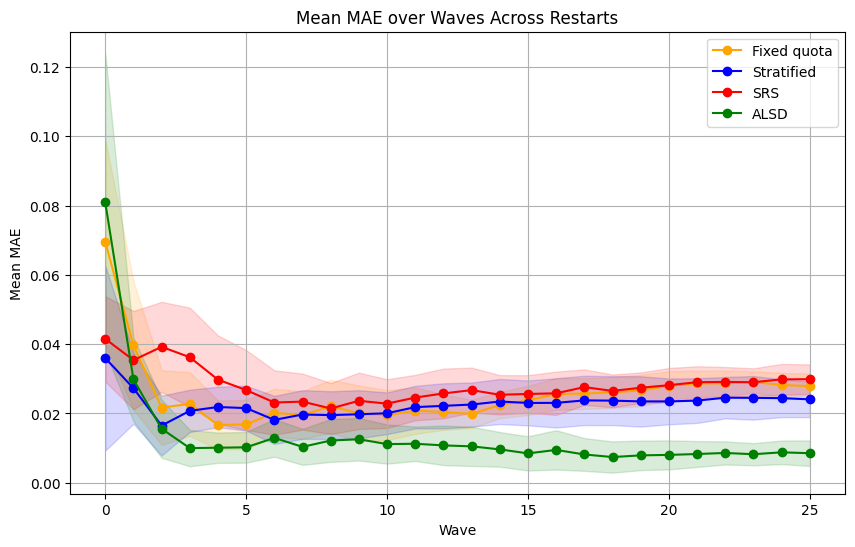

In [19]:
import matplotlib.pyplot as plt

summary_mae = (
    all_results
    .groupby(["method", "wave"], as_index=False)["mae"]
    .agg(mean_mae="mean", sd_mae="std")
)
plt.figure(figsize=(10, 6))
n_restarts = all_results["restart"].nunique()
for method, color in [
    ("Fixed quota", "orange"),
    ("Stratified", "blue"),
    ("SRS", "red"),
    ("ALSD", "green")]:
    dfm = summary_mae[summary_mae["method"] == method].copy()
    se = dfm["sd_mae"] / np.sqrt(n_restarts)

    plt.plot(dfm["wave"], dfm["mean_mae"], color=color, marker="o", label=method)
    plt.fill_between(
        dfm["wave"],
        dfm["mean_mae"] - 1.96 * se,
        dfm["mean_mae"] + 1.96 * se,
        color=color,
        alpha=0.15
    )
plt.xlabel("Wave")
plt.ylabel("Mean MAE")
plt.title("Mean MAE over Waves Across Restarts")
plt.grid(True)
plt.legend()
plt.show()